1. Data Import & Inspection

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("marketing_data1.csv")

# Inspect structure
print(df.shape)
df.head()
df.info()
df.describe()

# Check missing values
df.isnull().sum()


(2240, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4   Income               2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


2. Data Cleaning

In [ ]:
# Impute missing Income by Education + Marital_Status
df['Income'] = df.groupby(['Education','Marital_Status'])['Income'].transform(lambda x: x.fillna(x.mean()))

# Standardize categories (example: merge similar marital statuses)
df['Marital_Status'] = df['Marital_Status'].replace({'Together':'Married', 'Alone':'Single'})


3. Feature Engineering

In [ ]:
from datetime import datetime

# Age
df['Age'] = datetime.now().year - df['Year_Birth']

# Total Children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Total Spend
product_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
df['Total_Spend'] = df[product_cols].sum(axis=1)

# Total Purchases
purchase_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)


4. Exploratory Data Analysis

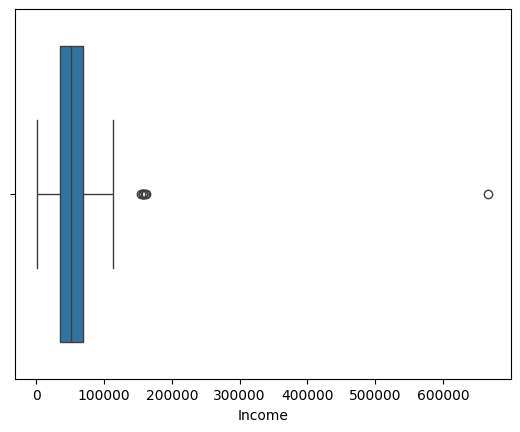

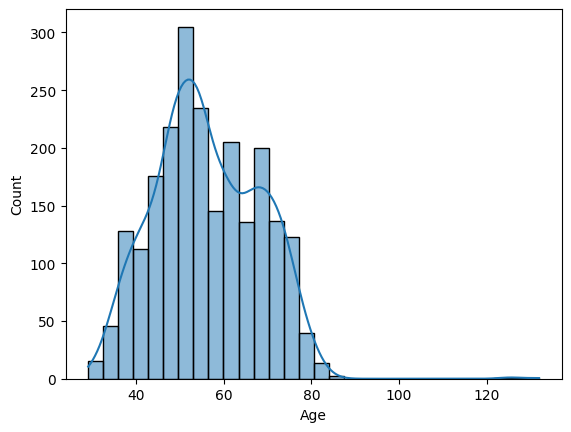

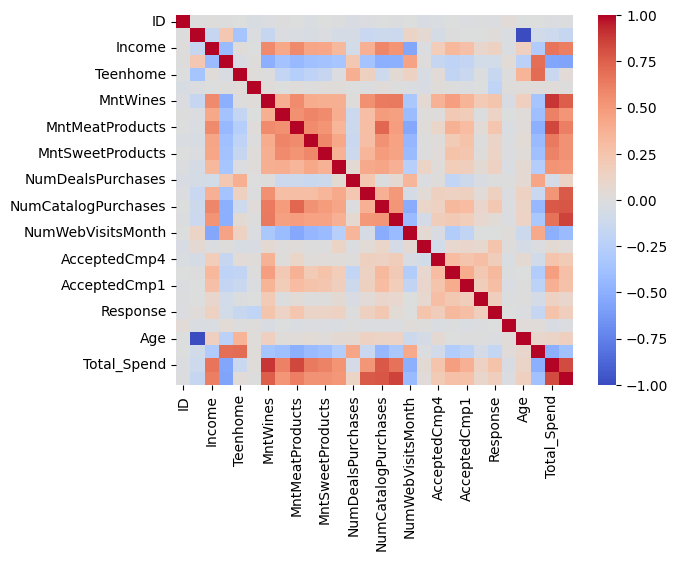

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Boxplot for Income
sns.boxplot(x=df['Income'])
plt.show()

# Histogram for Age
sns.histplot(df['Age'], bins=30, kde=True)
plt.show()

# Heatmap correlations (only for numeric columns)
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", annot=False)
plt.show()

5. Hypothesis Testing

In [ ]:
from scipy.stats import ttest_ind, chi2_contingency

# Older vs. in-store shopping
older = df[df['Age'] > 50]['NumStorePurchases']
younger = df[df['Age'] <= 50]['NumStorePurchases']
print(ttest_ind(older, younger))

# Kids vs. online shopping
kids = df[df['Total_Children'] > 0]['NumWebPurchases']
nokids = df[df['Total_Children'] == 0]['NumWebPurchases']
print(ttest_ind(kids, nokids))

# Cannibalization: correlation
print(df[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].corr())

# US vs. rest of world
us = df[df['Country'] == 'US']['Total_Purchases']
rest = df[df['Country'] != 'US']['Total_Purchases']
print(ttest_ind(us, rest))


TtestResult(statistic=np.float64(4.493210537290091), pvalue=np.float64(7.373005629031435e-06), df=np.float64(2238.0))
TtestResult(statistic=np.float64(-3.324463087423873), pvalue=np.float64(0.0009001778860238199), df=np.float64(2238.0))
                     NumWebPurchases  NumCatalogPurchases  NumStorePurchases
NumWebPurchases             1.000000             0.378376           0.502713
NumCatalogPurchases         0.378376             1.000000           0.518738
NumStorePurchases           0.502713             0.518738           1.000000
TtestResult(statistic=np.float64(1.4512386847675383), pvalue=np.float64(0.14685355981832418), df=np.float64(2238.0))


6. Insights & Visualization

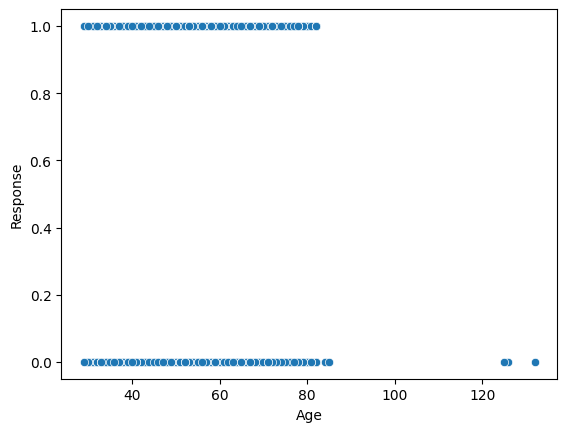

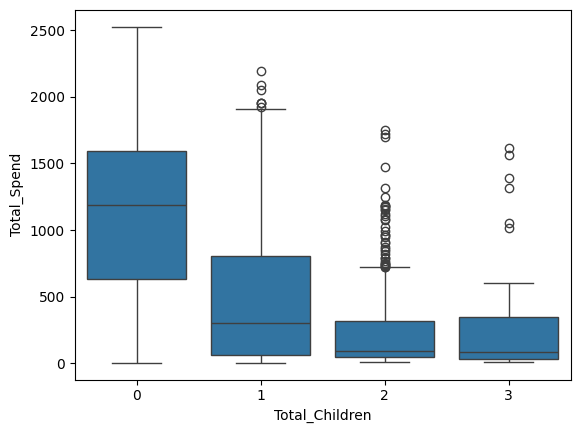

Complain,0,1
Education,,
2n Cycle,199,4
Basic,54,0
Graduation,1113,14
Master,368,2
PhD,485,1


In [ ]:
# Best/Worst products
df[product_cols].mean().sort_values(ascending=False)

# Age vs. campaign acceptance
sns.scatterplot(x='Age', y='Response', data=df)
plt.show()

# Country with highest acceptance
df.groupby('Country')['Response'].mean().sort_values(ascending=False)

# Children vs. spend
sns.boxplot(x='Total_Children', y='Total_Spend', data=df)
plt.show()

# Complaints vs. education
pd.crosstab(df['Education'], df['Complain'])
